# 1. Wczytanie danych
# 3. Trenowanie modelu SVM
# 4. Predykcja na zbiorze testowym
Work time:  135.02709889411926 s
# 5. Ocena modelu
Confusion Matrix:
[[82283   504]
 [  471 57286]]
True Positives (TP): 57286
True Negatives (TN): 82283
False Positives (FP): 504
False Negatives (FN): 471
4. Ocena modelu
Confusion Matrix:
[[82283   504]
 [  471 57286]]


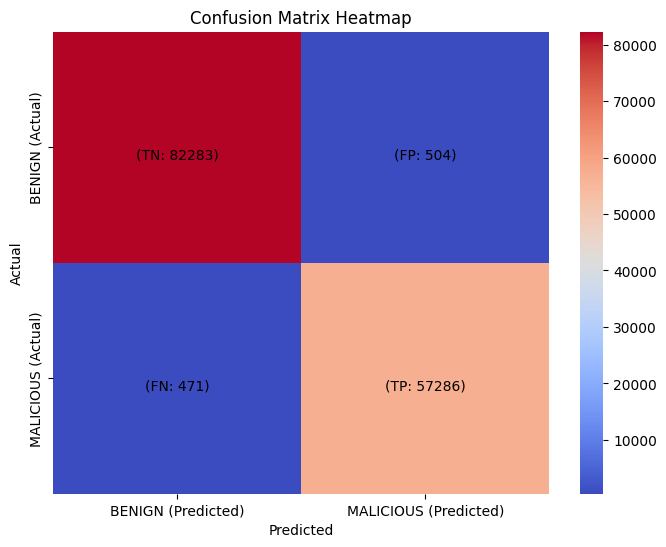

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      0.99      0.99     82787
   MALICIOUS       0.99      0.99      0.99     57757

    accuracy                           0.99    140544
   macro avg       0.99      0.99      0.99    140544
weighted avg       0.99      0.99      0.99    140544



In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

import warnings
warnings.filterwarnings("ignore")

# 1. Wczytanie danych
print("# 1. Wczytanie danych")
# day = 'Monday'
# day = 'Tuesday'
# day = 'Wednesday'
# day = 'Thursday'
day = 'Friday'
processed_filepath = './datasets/processed/'
data = pd.read_csv(processed_filepath + f'{day}.csv')
df = data.copy()

# 2. Przygotowanie danych
# print("# 2. Przygotowanie danych")
# # Usuwanie spacji z nazw kolumn
# df.columns = df.columns.str.replace(' ', '_')

# # Zastępowanie wartości nieskończonych i usuwanie brakujących danych
# df.replace([np.inf, -np.inf], np.nan, inplace=True)
# df.dropna(inplace=True)

# Zakładamy, że ostatnia kolumna to etykiety (np. BENIGN, Web Attack – Brute Force, itd.)
X = df.iloc[:, :-1].values  # Wszystkie kolumny oprócz ostatniej (cechy)
y = df.iloc[:, -1].values   # Ostatnia kolumna (etykiety)

# Przekształcenie etykiet na binarne: BENIGN = 0, cokolwiek innego = 1
# y = [0 if label == 'BENIGN' else 1 for label in y]

# Normalizacja cech (SVM wymaga danych w podobnej skali)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Podział na zestawy treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Trenowanie modelu SVM
print("# 3. Trenowanie modelu SVM")
start_time = time.time()
# Inicjalizacja modelu SVM z jądrem RBF (domyślne)
# svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42, probability=True)
from sklearn.svm import LinearSVC
svm_model = LinearSVC(class_weight='balanced', random_state=42)


# Trenowanie modelu
svm_model.fit(X_train, y_train)

# 4. Predykcja na zbiorze testowym
print("# 4. Predykcja na zbiorze testowym")
y_pred = svm_model.predict(X_test)
end_time = time.time() 
print("Work time: ", end_time - start_time, "s")

# 5. Ocena modelu
print("# 5. Ocena modelu")
# Macierz konfuzji
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Wyświetlenie wyników TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()
print(f'True Positives (TP): {TP}')
print(f'True Negatives (TN): {TN}')
print(f'False Positives (FP): {FP}')
print(f'False Negatives (FN): {FN}')

# Raport klasyfikacji
print("4. Ocena modelu")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Wizualizacja macierzy konfuzji
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='coolwarm', 
                 xticklabels=['BENIGN (Predicted)', 'MALICIOUS (Predicted)'], 
                 yticklabels=['BENIGN (Actual)', 'MALICIOUS (Actual)'])

labels = [[f'TN: {cm[0][0]}', f'FP: {cm[0][1]}'], 
          [f'FN: {cm[1][0]}', f'TP: {cm[1][1]}']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.5, f'\n({labels[i][j]})', 
                color='Black', ha='center', va='center', fontsize=10)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'MALICIOUS']))

In [2]:
import numpy as np
import os

TN, FP = cm[0]
FN, TP = cm[1]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

In [3]:
results_dir = './results/SVM/'
os.makedirs(results_dir, exist_ok=True) 
results_filepath = results_dir + f'SVM_{day}_model_results.txt'

with open(results_filepath, 'w') as f:
    f.write("==========================================================================================\n")
    f.write("===\n")
    f.write(f"{results_filepath}\n")
    f.write("===\n")
    f.write(f"Czas uczenia: {end_time - start_time:.2f} s\n")
    f.write(f"Macierz konfuzji:\n")
    f.write(f"[[ True Negatives (TN): {cm[0][0]}   False Positives (FP): {cm[0][1]} ]\n")
    f.write(f" [ False Negatives (FN): {cm[1][0]}   True Positives (TP): {cm[1][1]} ]]\n\n")
    f.write(f"Accuracy: {accuracy:.2%}\n")
    f.write(f"Precision (dla klasy ATTACK): {precision:.2%}\n")
    f.write(f"Recall (dla klasy ATTACK): {recall:.2%}\n")
    f.write(f"F1-score: {f1_score:.2%}\n")
    f.write("==========================================================================================\n")

In [4]:
y_pred_probs = svm_model.predict_proba(X_test)[:, 1]

def make_roc_plot():
    from sklearn.metrics import roc_curve, auc

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend()
    plt.grid()
    plt.show()

def make_precission_recall_plot():
    from sklearn.metrics import precision_recall_curve, average_precision_score

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)
    average_precision = average_precision_score(y_test, y_pred_probs)

    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, color='green', label=f'Precision-Recall Curve (AP = {average_precision:.2f})')
    plt.title('Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()


make_roc_plot()
make_precission_recall_plot()

AttributeError: 'LinearSVC' object has no attribute 'predict_proba'